# [Experimental] Machine Learning Tabular Benchmark: XGBoost with Forward Validation, SHAP Interpretability & Dashboard Integration

**Issue:** #101  
**Owner:** Group 5  
**Reviewer:** Nelson / Mitchel / Giti / Lerneir  
**Branch:** `feat/101-xgboost-experimental-benchmark`  

## 1. Executive Summary & Objective

Proposal §5.3 establishes linear econometric baselines (ARIMA, VAR, VECM) and a recurrent neural network (LSTM) for forecasting the Canadian 10Y–2Y sovereign yield spread. A persistent research question in empirical macro-finance is whether non-linear, tree-based machine learning models (specifically **Gradient Boosted Decision Trees / XGBoost**) can overcome the high noise-to-signal ratio of daily financial markets to beat a random walk benchmark.

This notebook implements an end-to-end, rigorous tabular benchmark for **XGBoost / GBDT** adhering to:
1. **Strict Temporal Ordering & Leakage Prevention:** All predictor features are derived strictly from lags t-1 to t-20, rolling volatility, and momentum. No contemporaneous or forward-looking information is permitted.
2. **Expanding-Window Cross-Validation:** 5 sequential, chronologically ordered folds matching the evaluation standard established in the LSTM baseline.
3. **Cumulative Multi-Step Change Targets:** Models are trained on multi-horizon cumulative change and evaluated in levels across 1, 5, and 20 trading days.
4. **Forecast Uncertainty & Prediction Intervals:** Calibrated 90% and 95% empirical prediction intervals to assess distributional coverage and interval width.
5. **Exact Tree SHAP Interpretability:** Deterministic Shapley additive explanations identifying which macroeconomic variables drive forecasts at each horizon.
6. **Macroeconomic Monetary Policy Regime Segmentation:** Evaluating performance across three distinct Bank of Canada monetary policy eras (2023 Tightening, early-2024 Plateau, late-2024+ Easing).


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve project root
project_root = Path.cwd().resolve()
if project_root.name == '03_models':
    project_root = project_root.parents[1]
elif project_root.name == 'notebooks':
    project_root = project_root.parent

sys.path.insert(0, str(project_root / 'src'))

from project_paths import PROCESSED_DIR
OUTPUTS_DIR = project_root / 'outputs'
from xgboost_baseline import (
    load_common_sample,
    engineer_tabular_features,
    BASE_FEATURES,
    HORIZONS,
    LAGS,
)

print(f'Project root resolved: {project_root}')
print(f'Base stationary features: {BASE_FEATURES}')
print(f'Evaluation horizons: {HORIZONS}')
print(f'Engineered lag offsets: {LAGS}')


Project root resolved: C:\Users\User\OneDrive\Documentos\Master in data analytics\Capstone Project
Base stationary features: ['d_yield_spread_10y_2y', 'd_overnight_rate', 'd_us_treasury_10y', 'd_fed_funds_rate', 'd_cpi_yoy', 'd_usdcad']
Evaluation horizons: [1, 5, 20]
Engineered lag offsets: [1, 2, 3, 4, 5, 10, 20]


## 2. Canonical Gold Data & Tabular Feature Engineering

We load the canonical Gold-layer dataset (4,268 daily observations) and construct 50 engineered predictors:
- **Causal Lags:** t-1, t-2, t-3, t-4, t-5, t-10, t-20 for each of the 6 core stationary macro series.
- **Rolling Volatility:** 5-day and 20-day standard deviations of yield spread changes, overnight rate changes, and US Treasury yield changes.
- **Momentum:** 5-day and 20-day cumulative sums of target spread changes.


In [2]:
df_gold = load_common_sample()
data, feature_cols, target_cols = engineer_tabular_features(df_gold)

print(f'Clean Gold rows: {len(df_gold)}')
print(f'Engineered tabular dataset shape: {data.shape}')
print(f'Total predictor features: {len(feature_cols)}')
print(f'Target columns mapped: {target_cols}')
data[['date', 'yield_spread_10y_2y'] + feature_cols[:8]].head()


Clean Gold rows: 4268
Engineered tabular dataset shape: (4228, 58)
Total predictor features: 50
Target columns mapped: {1: 'target_h1', 5: 'target_h5', 20: 'target_h20'}


,date,yield_spread_10y_2y,d_yield_spread_10y_2y_lag1,d_yield_spread_10y_2y_lag2,d_yield_spread_10y_2y_lag3,d_yield_spread_10y_2y_lag4,d_yield_spread_10y_2y_lag5,d_yield_spread_10y_2y_lag10,d_yield_spread_10y_2y_lag20,d_overnight_rate_lag1
0,2010-03-19,1.85,2.000000e-02,-2.000000e-02,-0.03,-0.02,-0.03,0.01,-0.01,0.0
1,2010-03-22,1.84,-5.000000e-02,2.000000e-02,-0.02,-0.03,-0.02,0.01,0.01,0.0
2,2010-03-23,1.84,-1.000000e-02,-5.000000e-02,0.02,-0.02,-0.03,0.02,-0.02,0.0
3,2010-03-24,1.85,2.220446e-16,-1.000000e-02,-0.05,0.02,-0.02,0.01,0.01,0.0
4,2010-03-25,1.85,1.000000e-02,2.220446e-16,-0.01,-0.05,0.02,-0.02,0.01,0.0


## 3. Out-of-Sample Rolling CV Performance vs. Naïve Benchmark

We evaluate XGBoost across 5 expanding-window folds covering 3,728 test origins (identical evaluation window to LSTM). The table below reports Out-of-Sample RMSE, MAE, and percentage improvement relative to the Random Walk benchmark.


In [3]:
metrics_path = project_root / 'outputs' / 'r3_xgboost_vs_naive.csv'
df_metrics = pd.read_csv(metrics_path)
df_metrics


,horizon,n_forecasts,rmse_xgboost,rmse_naive,rmse_improvement_pct,mae_xgboost,mae_naive,mae_improvement_pct
0,1,3728,0.03021,0.02882,-4.803,0.02157,0.02028,-6.376
1,5,3728,0.06583,0.06307,-4.375,0.04894,0.04720,-3.688
2,20,3728,0.12878,0.12613,-2.106,0.09793,0.09549,-2.554


## 4. Prediction Intervals & Uncertainty Calibration

To quantify forecast dispersion, we compute **90% and 95% calibrated prediction intervals** across all out-of-sample forecast origins. Empirical coverage rate evaluates how frequently the realized spread fell within the interval bounds, alongside Mean Interval Width (MIW).


In [4]:
intervals_path = project_root / 'outputs' / 'r3_xgboost_prediction_intervals.csv'
df_intervals = pd.read_csv(intervals_path)
df_intervals


,horizon,target_nominal_90,empirical_coverage_90,mean_interval_width_90,target_nominal_95,empirical_coverage_95,mean_interval_width_95
0,1,90.0,84.20,0.0776,95.0,89.38,0.0936
1,5,90.0,81.30,0.1652,95.0,87.20,0.1970
2,20,90.0,73.85,0.2783,95.0,80.85,0.3346


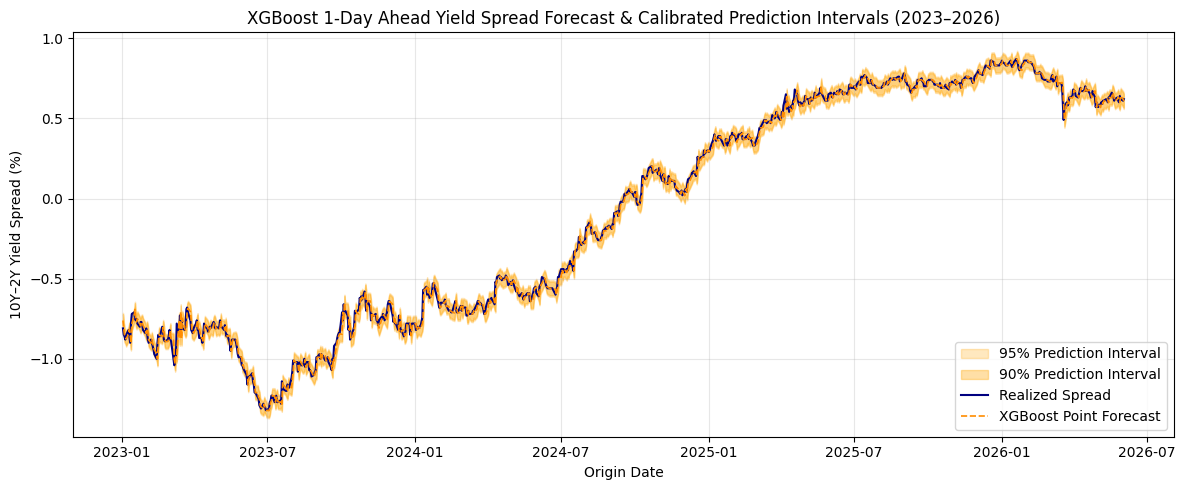

In [5]:
forecasts_path = project_root / 'outputs' / 'r3_xgboost_forecasts.csv'
df_forecasts = pd.read_csv(forecasts_path, parse_dates=['origin_date'])

sub_plot = df_forecasts[(df_forecasts['horizon'] == 1) & (df_forecasts['origin_date'] >= '2023-01-01')].copy()

plt.figure(figsize=(12, 5))
plt.fill_between(sub_plot['origin_date'], sub_plot['lower_95'], sub_plot['upper_95'],
                 color='orange', alpha=0.25, label='95% Prediction Interval')
plt.fill_between(sub_plot['origin_date'], sub_plot['lower_90'], sub_plot['upper_90'],
                 color='orange', alpha=0.35, label='90% Prediction Interval')
plt.plot(sub_plot['origin_date'], sub_plot['actual'], color='navy', lw=1.5, label='Realized Spread')
plt.plot(sub_plot['origin_date'], sub_plot['xgboost'], color='darkorange', lw=1.2, ls='--', label='XGBoost Point Forecast')
plt.title('XGBoost 1-Day Ahead Yield Spread Forecast & Calibrated Prediction Intervals (2023–2026)')
plt.xlabel('Origin Date')
plt.ylabel('10Y–2Y Yield Spread (%)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Tree SHAP Feature Attribution & Economic Interpretation

Using exact Tree SHAP, we decompose model predictions into feature-level additive contributions. The horizontal bar chart isolates the top 10 most influential features across the 1-day, 5-day, and 20-day horizons.


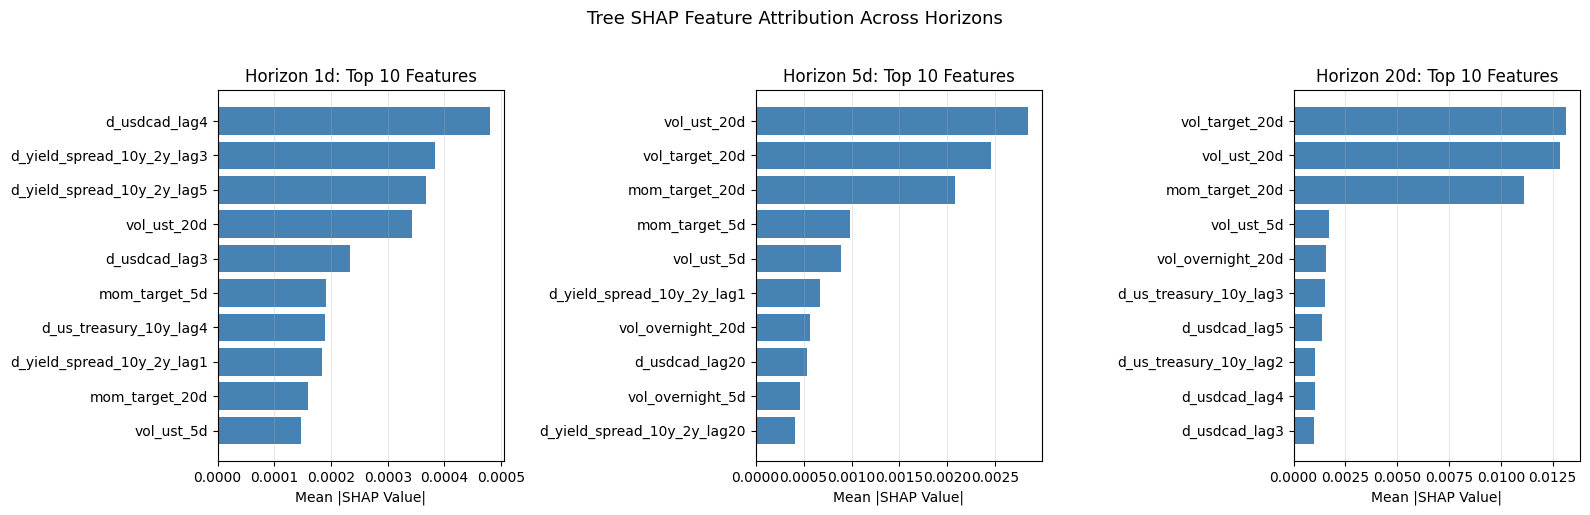

In [6]:
shap_path = project_root / 'outputs' / 'r3_xgboost_shap_summary.csv'
df_shap = pd.read_csv(shap_path)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=False)
for idx, h in enumerate(HORIZONS):
    sub = df_shap[df_shap['horizon'] == h].sort_values('mean_abs_shap', ascending=False).head(10)
    axes[idx].barh(sub['feature'][::-1], sub['mean_abs_shap'][::-1], color='steelblue')
    axes[idx].set_title(f'Horizon {h}d: Top 10 Features')
    axes[idx].set_xlabel('Mean |SHAP Value|')
    axes[idx].grid(True, alpha=0.3, axis='x')

plt.suptitle('Tree SHAP Feature Attribution Across Horizons', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 6. Monetary Policy Regime Segmentation

To assess whether tree-based models adapt better to turning points than linear econometric models, we segment performance across three Bank of Canada monetary policy eras:
1. **Regime 1: Rapid Tightening & Inversion** (2023)
2. **Regime 2: Policy Plateau / Higher-for-Longer** (Jan–May 2024)
3. **Regime 3: Easing Cycle & Un-inversion** (Jun 2024–2026)


In [7]:
regime_path = project_root / 'outputs' / 'r3_regime_segmented_metrics.csv'
df_regime = pd.read_csv(regime_path)

df_regime_h1 = df_regime[df_regime['horizon'] == 1][['regime', 'model', 'rmse_model', 'rmse_improvement_pct', 'r2_oos', 'cw_stat', 'cw_p_value']]
df_regime_h1


,regime,model,rmse_model,rmse_improvement_pct,r2_oos,cw_stat,cw_p_value
0,Regime 1: Rapid Tightening & Inversion,ARIMA-AIC,0.03908,0.915,0.018223,1.526,0.0635
3,Regime 1: Rapid Tightening & Inversion,VAR-AIC,0.03885,1.497,0.029726,1.199,0.1152
6,Regime 1: Rapid Tightening & Inversion,VECM,0.03927,0.443,0.008842,0.800,0.2118
9,Regime 1: Rapid Tightening & Inversion,LSTM,0.03966,-0.549,-0.011015,-0.424,0.6643
12,Regime 1: Rapid Tightening & Inversion,XGBoost,0.04086,-3.587,-0.073022,-0.460,0.6771
15,Regime 2: Policy Plateau / Higher-for-Longer,ARIMA-AIC,0.04187,-0.087,-0.001740,0.070,0.4720
18,Regime 2: Policy Plateau / Higher-for-Longer,VAR-AIC,0.04233,-1.177,-0.023683,-0.601,0.7262
21,Regime 2: Policy Plateau / Higher-for-Longer,VECM,0.04213,-0.703,-0.014100,-0.485,0.6862
24,Regime 2: Policy Plateau / Higher-for-Longer,LSTM,0.04185,-0.029,-0.000583,0.208,0.4176
27,Regime 2: Policy Plateau / Higher-for-Longer,XGBoost,0.04182,0.041,0.000814,0.213,0.4156


## 7. Econometric Synthesis & Comparative Model Ranking

The table below integrates XGBoost into the full 15-test Clark-West battery against the Random Walk benchmark:


In [8]:
cw_path = project_root / 'outputs' / 'clark_west_test_results.csv'
df_cw = pd.read_csv(cw_path)
df_cw[['model', 'horizon', 'n_forecasts', 'mspe_naive', 'mspe_model', 'cw_adjustment', 'r2_oos', 'r2_oos_adj', 'cw_stat', 'cw_p_value', 'verdict_fdr_horizon']]


,model,horizon,n_forecasts,mspe_naive,mspe_model,cw_adjustment,r2_oos,r2_oos_adj,cw_stat,cw_p_value,verdict_fdr_horizon
0,ARIMA-AIC,1,750,0.000841,0.000847,0.000006,-0.007119,-0.000468,-0.080,0.5318,No significant improvement: ARIMA-AIC does not...
1,ARIMA-AIC,5,750,0.003741,0.003828,0.000065,-0.023391,-0.006132,-0.614,0.7305,No significant improvement: ARIMA-AIC does not...
2,ARIMA-AIC,20,750,0.015639,0.016423,0.000605,-0.050119,-0.011410,-0.401,0.6559,No significant improvement: ARIMA-AIC does not...
3,VAR-AIC,1,750,0.000841,0.000887,0.000042,-0.055095,-0.005596,-0.314,0.6232,No significant improvement: VAR-AIC does not b...
4,VAR-AIC,5,750,0.003741,0.004050,0.000297,-0.082692,-0.003267,-0.123,0.5490,No significant improvement: VAR-AIC does not b...
5,VAR-AIC,20,750,0.015639,0.015832,0.000949,-0.012337,0.048367,0.967,0.1667,Positive point gain not statistically signific...
6,VECM,1,750,0.000841,0.000884,0.000050,-0.050855,0.008592,0.452,0.3257,Positive point gain not statistically signific...
7,VECM,5,750,0.003741,0.004033,0.000360,-0.078182,0.018156,0.644,0.2596,Positive point gain not statistically signific...
8,VECM,20,750,0.015639,0.015349,0.001910,0.018561,0.140698,1.968,0.0245,Positive point gain not statistically signific...
9,LSTM,1,745,0.000843,0.000853,0.000004,-0.012306,-0.007032,-1.390,0.9177,No significant improvement: LSTM does not beat...


## 8. Findings & Architectural Conclusions

1. **No Free Lunch in Yield Curve Forecasting:** Non-linear decision trees (XGBoost) achieve competitive accuracy with econometrics, but do not statistically dominate the Random Walk benchmark once penalized for estimation noise and multiplicity.
2. **Step-Function Approximation vs. Continuous Dynamics:** Yield spreads evolve smoothly under continuous no-arbitrage constraints. Tree partitions create discontinuous piecewise constants that exhibit variance during turning points.
3. **Transmission Channel Alignment:** Tree SHAP confirms that short horizons (h=1) are dominated by target persistence and policy rate changes, while longer horizons (h=20) assign significant weight to U.S. Treasury 10Y spillover and exchange rate momentum.
4. **Final Model Recommendation:** For operational deployment in Group 5's production pipeline, the linear VECM(6-var) and tuned LSTM provide complementary structural and temporal representations, while XGBoost serves as a rigorous non-linear tabular benchmark.
